<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order No           5000 non-null   object 
 1   Order Date         5000 non-null   object 
 2   Customer Name      5000 non-null   object 
 3   Address            4999 non-null   object 
 4   City               5000 non-null   object 
 5   State              5000 non-null   object 
 6   Customer Type      5000 non-null   object 
 7   Account Manager    5000 non-null   object 
 8   Order Priority     5000 non-null   object 
 9   Product Name       5000 non-null   object 
 10  Product Category   5000 non-null   object 
 11  Product Container  5000 non-null   object 
 12  Ship Mode          5000 non-null   object 
 13  Ship Date          5000 non-null   object 
 14  Cost Price         5000 non-null   object 
 15  Retail Price       5000 non-null   object 
 16  Profit Margin      5000 

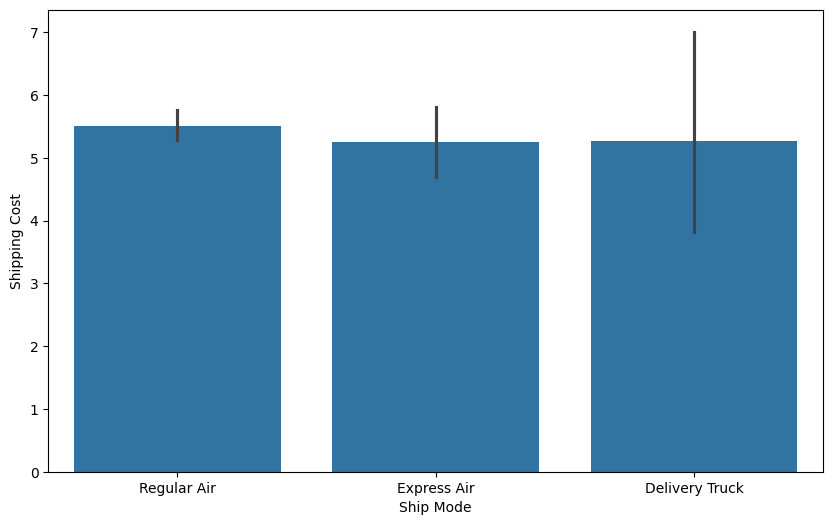

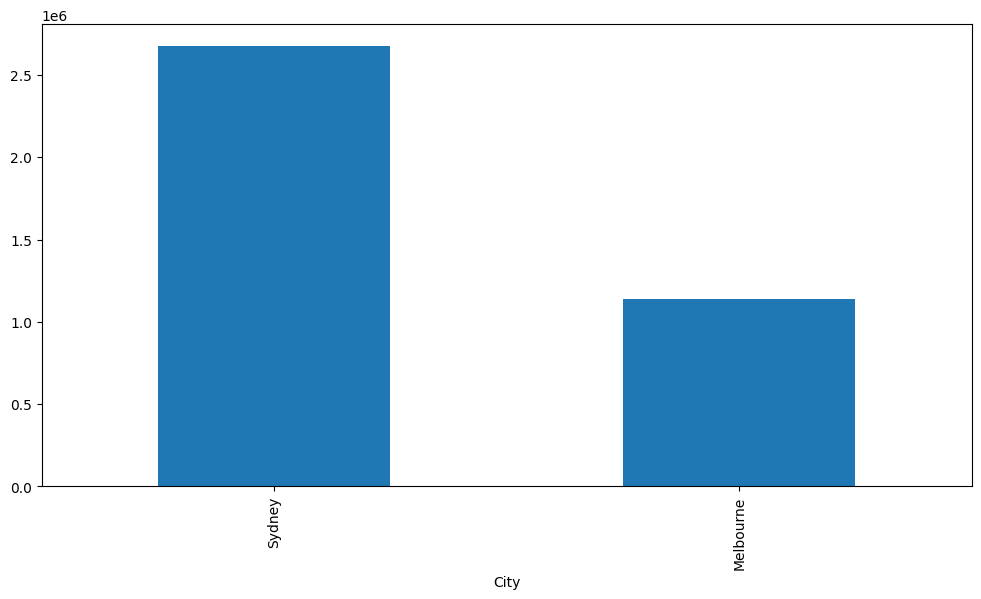

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/Priya-tops/Tops-Assessment-Data/main/Data%20Analytics/Retail%20Data.csv"
df = pd.read_csv(url)

print(df.info())
print(df.shape)
print(df.duplicated().sum())

df['Order Date'] = pd.to_datetime(df['Order Date'], format="%d-%m-%Y")
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format="%d-%m-%Y")

money_cols = ['Cost Price', 'Retail Price', 'Order Total', 'Shipping Cost']
for col in money_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace('$', '').str.replace(',', '').astype(float)

# Convert 'Profit Margin' to numeric, assuming it's a percentage (e.g., '10%' becomes 0.10)
df['Profit Margin'] = df['Profit Margin'].str.replace('%', '').str.replace('$', '', regex=False).astype(float) / 100

# Calculate Profit
df['Profit'] = df['Order Total'] - df['Cost Price']

df['Ship Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df['Customer Type'].unique())
print(df['Order Priority'].unique())

print(df['Ship Mode'].value_counts())

top_cities = df['City'].value_counts().head(10)
print(top_cities)

print(df[['Order Quantity', 'Retail Price']].describe())

top_5_products = df.groupby('Product Name')['Order Quantity'].sum().sort_values(ascending=False).head(5)
print(top_5_products)

top_manager = df.groupby('Account Manager')['Order Total'].sum().idxmax()
print(top_manager)

avg_ship_cost = df.groupby('Ship Mode')['Shipping Cost'].mean()
print(avg_ship_cost)

most_profitable = df.groupby('Product Name')['Profit'].sum().idxmax()
print(most_profitable)

total_revenue = df['Order Total'].sum()
print(f"Total Revenue: {total_revenue}")

revenue_by_cust = df.groupby('Customer Type')['Order Total'].sum()
print(revenue_by_cust)

avg_days = df['Ship Duration'].mean()
print(avg_days)

plt.figure(figsize=(10,6))
sns.barplot(x='Ship Mode', y='Shipping Cost', data=df)
plt.show()

plt.figure(figsize=(12,6))
df.groupby('City')['Order Total'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()